# Solutions and states

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lldddv2/relatipy/blob/main/docs/tutorials/04-solutions-and-states.ipynb)

This tutorial explores what a `Solution` contains:

- times;
- Cartesian, spherical and Boyer--Lindquist coordinates;
- coordinate velocities and four-velocities, their shapes and units;
- how to select stored samples and interpolate with `Solution.at`;
- how to read osculating orbital elements and their `defined` mask.

In [ ]:
%pip install -Uq relatipy

In [1]:
import numpy as np
from astropy import units as u
from astropy.constants import c

import relatipy as rp

## 1. A bound Kerr orbit

We integrate a stable bound orbit around a Kerr black hole of
$10^6\,M_\odot$ with spin $0.9$, using the Kerr parameters $p = 6\,r_s$, where
$r_s = 2GM/c^2$ is the Schwarzschild radius, $e = 0.3$ and $x = 0.8$. The
semi-latus rectum is given in kilometres, so output lengths are reported in
kilometres; times keep the unit of the initial proper time (seconds by default).
We use $T_0 = r_s/c = 2GM/c^3$ as the time scale.

In [2]:
bh = rp.Kerr(mass=1e6 * u.Msun, spin=0.9)
T0 = (bh.r_s / c).to(u.s)
orbit = bh.orbit(p=6 * bh.r_s.to(u.km), e=0.3, x=0.8)
sol = orbit.solve(tau_span=(0 * u.s, 1000 * T0))

print("status:", sol.status)
print("stored samples:", len(sol))
print("tau range:", sol.tau[0], "to", sol.tau[-1])

status: 0
stored samples: 391
tau range: 0.0 s to 9850.981895282535 s


`plot_evol` draws stored components against time. With `coords="bl"` and
`Phi=False` it shows the Boyer--Lindquist radius and polar angle against proper
time: the radius oscillates between periapsis and apoapsis while the polar angle
oscillates around the equator.

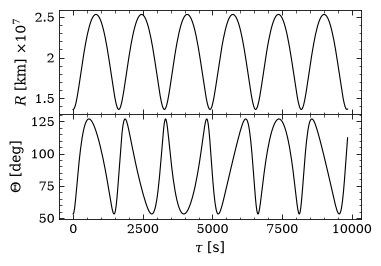

In [3]:
fig, axes = sol.plot_evol(time="tau", coords="bl", Phi=False)

## 2. Times

A solution stores proper time `tau` and coordinate time `t`, each a
one-dimensional quantity with one entry per stored sample. Without `tau_eval`,
the samples are the initial state plus every accepted native step.

In [4]:
print("tau:", sol.tau.shape, sol.tau.unit)
print("t  :", sol.t.shape, sol.t.unit)
print("t / tau at the last sample:", (sol.t[-1] / sol.tau[-1]).to(u.one))

tau: (391,) s
t  : (391,) s
t / tau at the last sample: 1.1350566204829253


## 3. Positions in three coordinate families

* Cartesian: `xyz` with shape `(n, 3)`, and the components `x`, `y`, `z`;
* spherical: `r`, `theta`, `phi`;
* Boyer--Lindquist: `R`, `Theta`, `Phi`.

Grouped views `txyz`, `trqp` and `tRQP` bundle each family with `t`. The
spherical radius `r` and the Boyer--Lindquist radius `R` are different
coordinates in a spinning spacetime, so they generally do not agree:

In [5]:
print("xyz:", sol.xyz.shape, sol.xyz.unit)
for name in ("r", "theta", "phi", "R", "Theta", "Phi"):
    q = getattr(sol, name)
    print(f"{name:5s} shape={q.shape}  unit={q.unit}  first={q[0]:.6g}")

xyz: (391, 3) km
r     shape=(391,)  unit=km  first=1.36718e+07 km
theta shape=(391,)  unit=rad  first=0.929564 rad
phi   shape=(391,)  unit=rad  first=0 rad
R     shape=(391,)  unit=km  first=1.36304e+07 km
Theta shape=(391,)  unit=rad  first=0.927295 rad
Phi   shape=(391,)  unit=rad  first=0 rad


## 4. Velocities and four-velocities

Two kinds of velocity are available:

* coordinate velocities, derivatives with respect to coordinate time $t$:
  `vxyz` (shape `(n, 3)`), `vx`, `vy`, `vz`, spherical `vr`, `vtheta`,
  `vphi`, and Boyer--Lindquist `vR`, `vTheta`, `vPhi`;
* spatial four-velocity components, derivatives with respect to proper time
  $\tau$: `uxyz`, `ux`, `uy`, `uz`, `ur`, `utheta`, `uphi`, `uR`, `uTheta`,
  `uPhi`, plus the dimensionless temporal component `ut`.

Radial and Cartesian components have units of length per time; angular
components have units of angle per time.

In [6]:
names = ("vxyz", "vR", "vTheta", "vPhi", "uxyz", "uR", "uTheta", "uPhi", "ut")
for name in names:
    q = getattr(sol, name)
    unit = q.unit.to_string() or "dimensionless"
    print(f"{name:7s} shape={str(q.shape):9s} unit={unit}")

vxyz    shape=(391, 3)  unit=km / s
vR      shape=(391,)    unit=km / s
vTheta  shape=(391,)    unit=rad / s
vPhi    shape=(391,)    unit=rad / s
uxyz    shape=(391, 3)  unit=km / s
uR      shape=(391,)    unit=km / s
uTheta  shape=(391,)    unit=rad / s
uPhi    shape=(391,)    unit=rad / s
ut      shape=(391,)    unit=dimensionless


For an orbit sampled at the same events, the spatial four-velocity equals the
coordinate velocity multiplied by $u^t = dt/d\tau$. We can check this
relation on the stored samples:

In [7]:
expected = sol.ut[:, None] * sol.vxyz
rel = np.max(np.abs((sol.uxyz - expected) / np.abs(sol.uxyz).max()).to_value(u.one))
print("max relative difference between uxyz and ut * vxyz:", f"{rel:.2e}")

max relative difference between uxyz and ut * vxyz: 2.26e-16


## 5. Selecting stored samples

Indexing a solution selects stored samples without interpolation. An integer
returns a scalar `State` (components are scalars and `xyz` has shape `(3,)`);
a slice, an integer array or a boolean mask returns a vectorized `State`.

In [8]:
first = sol[0]
every_50 = sol[::50]
far = sol[sol.R > 8 * bh.r_s]

print("integer:", isinstance(first, rp.State), first.tau.shape, first.xyz.shape, first.tau)
print("slice  :", every_50.xyz.shape)
print("mask   :", far.tau.shape, "samples with R > 8 r_s")

integer: True () (3,) 0.0 s
slice  : (8, 3)
mask   : (67,) samples with R > 8 r_s


`solve` leaves the orbit untouched, so the orbit's current point is still its
starting point and matches the first stored sample `sol[0]`.

In [9]:
print("orbit R:", orbit.R)
print("equals sol.R[0]:", bool(orbit.R == sol.R[0]))
print("same xyz as sol[0]:", np.allclose(orbit.xyz, sol[0].xyz))

orbit R: 13630384.96661654 km
equals sol.R[0]: True
same xyz as sol[0]: True


## 6. Read-only arrays

Stored arrays are protected against in-place modification. Copy an array
before changing it.

In [10]:
try:
    sol.xyz[0, 0] = 0 * u.km
except ValueError as exc:
    print("ValueError:", exc)

xyz = sol.xyz.copy()        # an independent, writable copy
xyz[0, 0] = 0 * u.km
print("copy modified, original unchanged:", sol.xyz[0, 0])

ValueError: assignment destination is read-only
copy modified, original unchanged: 10956014.918006444 km


## 7. Querying arbitrary times with `Solution.at`

`sol.at(tau=...)` or `sol.at(t=...)` accepts exactly one Astropy time,
scalar or one-dimensional:

- a scalar query returns a scalar `State`;
- a sequence returns a vectorized `State`;
- times that coincide with stored samples return those samples exactly;
- between samples, Cartesian position and coordinate velocity are interpolated
  with cubic splines and the remaining views are reconstructed in the Kerr chart.

The orbit is not reintegrated.

In [11]:
point = sol.at(tau=1000 * u.s)
print("scalar query :", point.tau, point.xyz.shape)

grid = np.linspace(0, 9000, 7) * u.s
series = sol.at(tau=grid)
print("series query :", series.tau.shape, series.xyz.shape)

exact = sol.at(tau=sol.tau[10])
print("exact sample :", bool(np.all(exact.xyz == sol.xyz[10])))

by_t = sol.at(t=2000 * u.s)
print("coordinate-time query: t =", by_t.t, "-> tau =", by_t.tau)

scalar query : 1000.0 s (3,)
series query : (7,) (7, 3)
exact sample : True
coordinate-time query: t = 2000.0 s -> tau = 1754.3336760905063 s


Queries outside the stored proper-time domain are rejected:

In [12]:
try:
    sol.at(tau=sol.tau[-1] + 1 * u.s)
except ValueError as exc:
    print("ValueError:", exc)

ValueError: tau lies outside the stored solution domain


A query halfway between two stored samples returns a state that lies between
them. A stored sample is an accepted step; interpolated states carry
interpolation error in addition to the integration error.

In [13]:
i = 200
mid = sol.at(tau=0.5 * (sol.tau[i] + sol.tau[i + 1]))
rs = bh.r_s.to(u.km)
print(f"stored  R[{i}]     = {(sol.R[i] / rs).to_value(u.one):.6f} r_s")
print(f"interpolated R    = {(mid.R / rs).to_value(u.one):.6f} r_s")
print(f"stored  R[{i + 1}]     = {(sol.R[i + 1] / rs).to_value(u.one):.6f} r_s")

stored  R[200]     = 4.676515 r_s
interpolated R    = 4.699328 r_s
stored  R[201]     = 4.725549 r_s


## 8. Osculating orbital elements

`orbital_elements()` on an `Orbit`, a `State` or a `Solution` returns the
classical Kepler elements $(a, e, i, \Omega, \omega, f)$ of the
instantaneous conic computed from the Cartesian position and coordinate
velocity. They are **not** the Kerr parameters $(p, e, x)$ used to build this
orbit, and they are not constants of a Kerr geodesic: they change along the
trajectory.

In [14]:
elements = sol.orbital_elements()
print("a    :", elements.a.shape, elements.a.unit)
print("e    :", type(elements.e).__name__, elements.e.shape)
print("inc  :", elements.inc.unit)
print("Kerr input e = 0.3, initial osculating e =", f"{elements.e[0]:.4f}")
print("osculating e range along the orbit:", f"{elements.e.min():.4f} to {elements.e.max():.4f}")

a    : (391,) km
e    : ndarray (391,)
inc  : rad
Kerr input e = 0.3, initial osculating e = 0.1460
osculating e range along the orbit: 0.1460 to 0.2597


With `coords="elements"`, `plot_evol` draws the osculating semi-major axis,
eccentricity and true anomaly of every stored sample, which makes their
variation along the Kerr orbit visible.

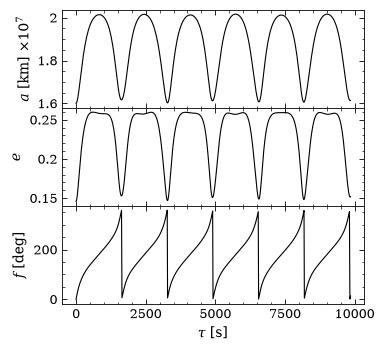

In [15]:
fig, axes = sol.plot_evol(time="tau", coords="elements")

### 8.1 The `defined` mask

Some elements can be undefined. When the angular momentum of the
instantaneous conic is too small to define an orbital plane, the four angles
are `NaN`; an exactly zero computed Kepler energy gives `a = +inf`, which
counts as defined. The read-only boolean `defined` mask has columns
`(a, e, inc, Omega, omega, f)`, with shape `(6,)` for one state and `(n, 6)`
for a series.

In [16]:
print("solution mask shape:", elements.defined.shape)
print("all defined:", bool(elements.defined.all()))

radial = bh.orbit(x=5 * bh.r_s)        # released from rest: radial state
radial_elements = radial.orbital_elements()
print("radial state mask  :", radial_elements.defined)
print("radial state inc   :", radial_elements.inc)

solution mask shape: (391, 6)
all defined: True
radial state mask  : [ True  True False False False False]
radial state inc   : nan rad


A radial or parabolic osculating conic only describes the instantaneous
Kepler representation; it does not classify the full Kerr trajectory.
Interpolated states from `Solution.at` get their own reconstructed elements,
so check `state.orbital_elements().defined` before using the angles.

## Next steps

* [Constants of motion](07-constants-of-motion.ipynb): $E$, $L_z$ and $Q$ along a solution, and the drift of each method.
* [Integration controls](03-integration-controls.ipynb): methods, tolerances,
  step limits and integration outcomes.
* [Plotting](05-plotting.ipynb): built-in trajectory and evolution plots.
* {doc}`../user-guide/usage`: querying solutions and osculating elements.
* {doc}`../reference/geodesic` and {doc}`../reference/coordinates`: API
  reference for `Solution`, `State` and `OrbitalElements`.